# 02 — Preprocessing: Preparing Extreme Events for DBSCAN
**Project:** GB Compound Hazards Risk Prioritization  
**Course:** Artificial Intelligence in Human Water Systems  

---
## Objectives
- Load pre-filtered extreme observations (p0005) from EDA output
- Convert spatiotemporal data into point format for DBSCAN
- Build a space-time cube representation (latitude, longitude, time)
- Normalize coordinates for DBSCAN distance calculation
- Save formatted point arrays ready for clustering


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Extreme Points from EDA

In [2]:
rain_df = pd.read_parquet('../data/processed/rain_extreme_points.parquet')
wind_df = pd.read_parquet('../data/processed/wind_extreme_points.parquet')

# Reset index to access lat, lon, time as columns
rain_df = rain_df.reset_index()
wind_df = wind_df.reset_index()

print('Rain extreme points:')
print(rain_df.head())
print(f'Shape: {rain_df.shape}')

print('\nWind extreme points:')
print(wind_df.head())
print(f'Shape: {wind_df.shape}')

Rain extreme points:
   index                time  latitude  longitude  precipitation
0      0 2019-09-01 07:00:00      60.0      -7.00       0.041438
1      1 2019-09-01 07:00:00      60.0      -6.75       0.037230
2      2 2019-09-01 07:00:00      60.0      -6.50       0.037230
3      3 2019-09-01 07:00:00      60.0      -6.25       0.033830
4      4 2019-09-01 07:00:00      60.0      -6.00       0.028651
Shape: (3494184, 5)

Wind extreme points:
   index                time  latitude  longitude       wind
0      0 2019-09-01 07:00:00      60.0      -7.00  12.224866
1      1 2019-09-01 07:00:00      60.0      -6.75  12.443558
2      2 2019-09-01 07:00:00      60.0      -6.50  12.588983
3      3 2019-09-01 07:00:00      60.0      -6.25  12.636718
4      4 2019-09-01 07:00:00      60.0      -6.00  12.619511
Shape: (3754944, 5)


## 3. Build Space-Time Cube

Following Tilloy et al. (2022), we represent each extreme observation as a point in a 3D space-time cube:
- Spatial dimensions: latitude, longitude (normalized by 0.25°)
- Temporal dimension: time (normalized to hours)

The spatiotemporal ratio r = 4 h/° means 0.25° in space ≈ 1h in time.

In [26]:
def build_spacetime_points(df, value_col, resolution=0.25):
    # Normalize latitude and longitude by grid resolution
    # So 1 unit = 1 grid cell (0.25 degrees)
    norm_lat = (df['latitude'].values - df['latitude'].min()) / resolution
    norm_lon = (df['longitude'].values - df['longitude'].min()) / resolution
    
    # Normalize time: 1 unit = 1 hour
    t0 = pd.Timestamp('2019-09-01 07:00:00')
    norm_time = (pd.to_datetime(df['time']) - t0).dt.total_seconds() / 3600
    
    points = np.column_stack([norm_lat, norm_lon, norm_time.values])
    values = df[value_col].values
    
    return points, values

rain_points, rain_values = build_spacetime_points(rain_df, 'precipitation')
wind_points, wind_values = build_spacetime_points(wind_df, 'wind')

print(f'Rain points ranges:')
print(f'  Lat units (grid cells): {rain_points[:,0].min():.1f} to {rain_points[:,0].max():.1f}')
print(f'  Lon units (grid cells): {rain_points[:,1].min():.1f} to {rain_points[:,1].max():.1f}')
print(f'  Time units (hours):     {rain_points[:,2].min():.1f} to {rain_points[:,2].max():.1f}')

Rain points ranges:
  Lat units (grid cells): 0.0 to 52.0
  Lon units (grid cells): 0.0 to 40.0
  Time units (hours):     0.0 to 1607.0


## 4. Verify Normalization

In [22]:
print('Rain points ranges after normalization:')
print(f'  Norm latitude:  {rain_points[:,0].min():.1f} to {rain_points[:,0].max():.1f} units')
print(f'  Norm longitude: {rain_points[:,1].min():.1f} to {rain_points[:,1].max():.1f} units')
print(f'  Time (hours):   {rain_points[:,2].min():.0f} to {rain_points[:,2].max():.0f} hours')

print('\nWind points ranges after normalization:')
print(f'  Norm latitude:  {wind_points[:,0].min():.1f} to {wind_points[:,0].max():.1f} units')
print(f'  Norm longitude: {wind_points[:,1].min():.1f} to {wind_points[:,1].max():.1f} units')
print(f'  Time (hours):   {wind_points[:,2].min():.0f} to {wind_points[:,2].max():.0f} hours')

Rain points ranges after normalization:
  Norm latitude:  0.0 to 52.0 units
  Norm longitude: 0.0 to 40.0 units
  Time (hours):   0 to 1607 hours

Wind points ranges after normalization:
  Norm latitude:  0.0 to 52.0 units
  Norm longitude: 0.0 to 40.0 units
  Time (hours):   0 to 1727 hours


## 5. k-NN Distance Plot — Choosing ε for DBSCAN

We use the k-NN distance plot to identify the optimal ε parameter for DBSCAN. The "knee" in the plot separates core cluster points (low k-NN distance) from noise points (high k-NN distance), following Tilloy et al. (2022).

Computing k-NN distances for precipitation (k=10)...
  Using random sample of 50,000 points out of 3,494,184


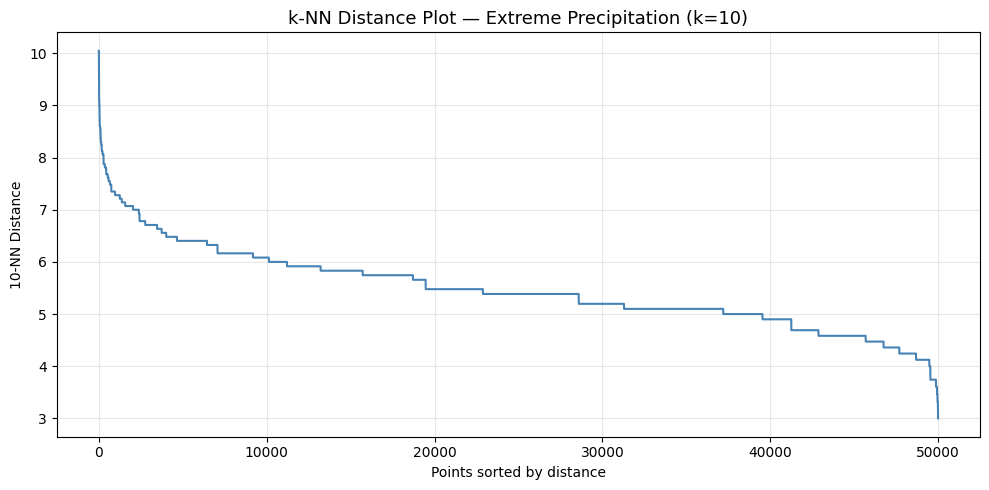


Computing k-NN distances for wind (k=10)...
  Using random sample of 50,000 points out of 3,754,944


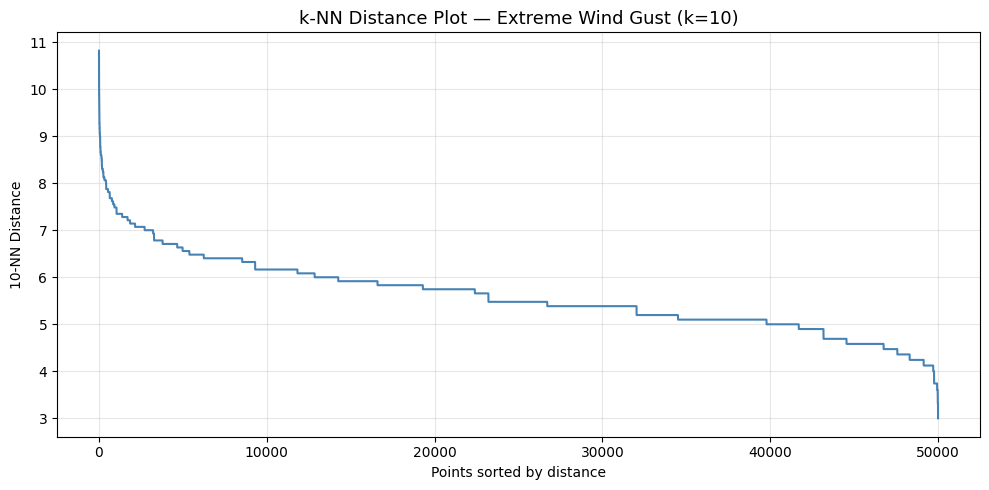

In [23]:
from sklearn.neighbors import NearestNeighbors

def plot_knn_distances(points, k=10, sample_size=50000, title='k-NN Distance Plot'):
    """
    Plot sorted k-NN distances to identify optimal epsilon for DBSCAN.
    Uses a random sample for computational efficiency.
    """
    # Sample for efficiency on large datasets
    if len(points) > sample_size:
        idx = np.random.choice(len(points), sample_size, replace=False)
        sample = points[idx]
        print(f'  Using random sample of {sample_size:,} points out of {len(points):,}')
    else:
        sample = points
    
    nbrs = NearestNeighbors(n_neighbors=k).fit(sample)
    distances, _ = nbrs.kneighbors(sample)
    distances = np.sort(distances[:, k-1])[::-1]
    
    plt.figure(figsize=(10, 5))
    plt.plot(distances, color='steelblue')
    plt.title(title, fontsize=13)
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{k}-NN Distance')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    return distances

print('Computing k-NN distances for precipitation (k=10)...')
rain_distances = plot_knn_distances(
    rain_points, k=10,
    title='k-NN Distance Plot — Extreme Precipitation (k=10)'
)
plt.savefig('../outputs/figures/02_knn_distances_rain.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nComputing k-NN distances for wind (k=10)...')
wind_distances = plot_knn_distances(
    wind_points, k=10,
    title='k-NN Distance Plot — Extreme Wind Gust (k=10)'
)
plt.savefig('../outputs/figures/02_knn_distances_wind.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Define DBSCAN Parameters

> **Instructions:** Look at the k-NN distance plots above and identify the "knee" — the point where the curve starts to rise steeply. The distance value at the knee is your ε. Update the values below accordingly.

Following Tilloy et al. (2022): ε_rain ≈ 2.45, ε_wind ≈ 2.24, min_samples = 10

In [24]:
# ============================================================
# DBSCAN PARAMETERS — adjust based on k-NN plots above
# ============================================================
PARAMS = {
    'rain': {
        'eps': 0.018,
        'min_samples': 10
    },
    'wind': {
        'eps': 0.018,
        'min_samples': 10
    }
}

print('DBSCAN parameters:')
for hazard, params in PARAMS.items():
    print(f'  {hazard}: eps={params["eps"]}, min_samples={params["min_samples"]}')

DBSCAN parameters:
  rain: eps=0.018, min_samples=10
  wind: eps=0.018, min_samples=10


## 7. Save Preprocessed Point Arrays

In [27]:
import json

# Save point arrays
np.save('../data/processed/rain_points.npy', rain_points)
np.save('../data/processed/rain_values.npy', rain_values)
np.save('../data/processed/wind_points.npy', wind_points)
np.save('../data/processed/wind_values.npy', wind_values)

# Save DBSCAN parameters
with open('../data/processed/dbscan_params.json', 'w') as f:
    json.dump(PARAMS, f, indent=2)

# Save reference time for inverse transformation later
t0_rain = str(rain_df['time'].min())
t0_wind = str(wind_df['time'].min())
with open('../data/processed/time_references.json', 'w') as f:
    json.dump({'rain': t0_rain, 'wind': t0_wind}, f, indent=2)

print('Saved:')
print('  data/processed/rain_points.npy')
print('  data/processed/rain_values.npy')
print('  data/processed/wind_points.npy')
print('  data/processed/wind_values.npy')
print('  data/processed/dbscan_params.json')
print('  data/processed/time_references.json')

Saved:
  data/processed/rain_points.npy
  data/processed/rain_values.npy
  data/processed/wind_points.npy
  data/processed/wind_values.npy
  data/processed/dbscan_params.json
  data/processed/time_references.json
